In [1]:
# ! pip install astroML

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from astroML.stats import sigmaG

In [3]:
# cloudy is 0, clear is 1
start_day = 0
p0_0 = 0.5
p1_0 = 1-p0_0
p0_1 = 0.1
p1_1 = 1-p0_1

In [4]:
def MC(today):
  if today == 0:
    return np.random.choice([0, 1], p=[p0_0, p1_0])
  if today == 1:
    return np.random.choice([0, 1], p=[p0_1, p1_1])

In [5]:
N = 100000
counter_0 = 0
counter_1 = 0
days = np.zeros(N)
days[0] = start_day

p_cloudy = np.zeros(N)
p_cloudy[0] = 1
p_clear = np.zeros(N)

for i in range(N-1):
  days[i+1] = MC(days[i])
  if days[i+1] == 0:
    counter_0 += 1
  p_cloudy[i+1] = counter_0/(i+1)
  if days[i+1] == 1:
    counter_1 += 1
  p_clear[i+1] = counter_1/(i+1)

In [6]:
# there is a burn-in phase that needs to be discarded since the chain has not been stationary yet
burn = 5000

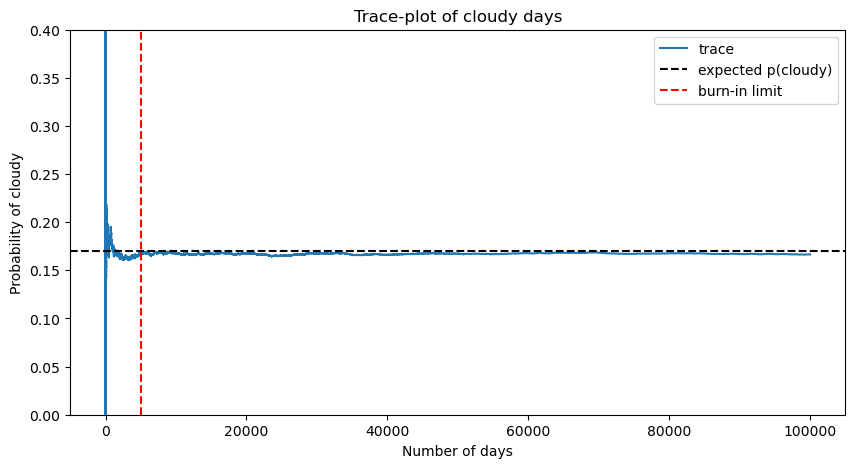

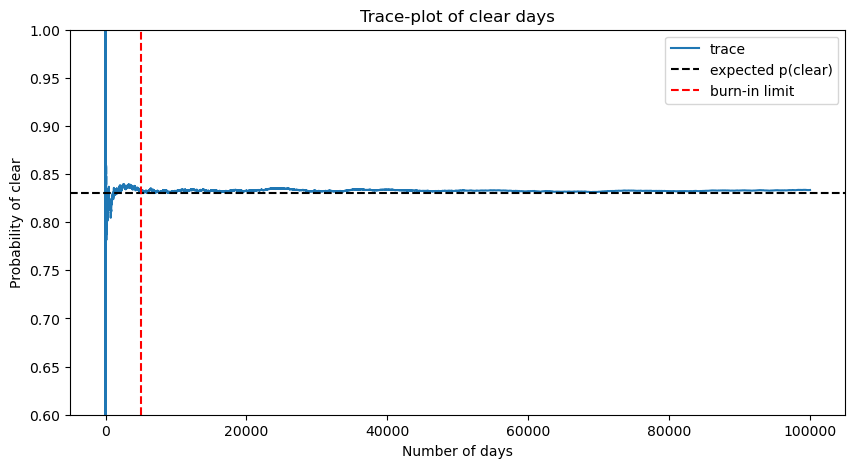

In [7]:
plt.figure(figsize=(10,5))
plt.plot(np.arange(0,N,1), p_cloudy, label="trace")
plt.axhline(y=0.17, color='k', linestyle='--', label="expected p(cloudy)")
plt.axvline(x=burn, color='r', linestyle='--', label="burn-in limit")
plt.xlabel('Number of days')
plt.ylabel('Probability of cloudy')
plt.title("Trace-plot of cloudy days")
plt.ylim(0.0, 0.4)
plt.legend(loc="upper right")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(np.arange(0,N,1), p_clear, label="trace")
plt.axhline(y=0.83, color='k', linestyle='--', label="expected p(clear)")
plt.axvline(x=burn, color='r', linestyle='--', label="burn-in limit")
plt.xlabel('Number of days')
plt.ylabel('Probability of clear')
plt.title("Trace-plot of clear days")
plt.ylim(0.6, 1.0)
plt.legend(loc="upper right")
plt.show()

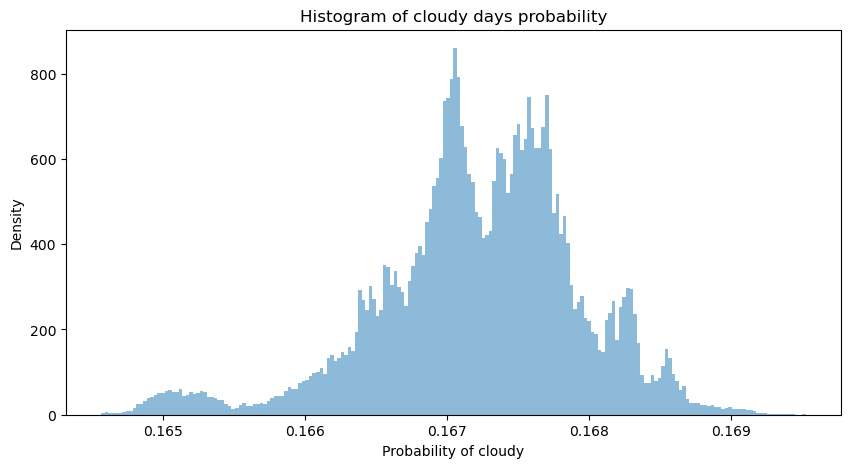

In [8]:
plt.figure(figsize=(10,5))
plt.hist(p_cloudy[burn:], bins=200, density=True, alpha=0.5)
plt.title("Histogram of cloudy days probability")
plt.xlabel('Probability of cloudy')
plt.ylabel('Density')
plt.show()

In [9]:
print("Probability of cloudy: summary statistics\n")
print("Median = {:.4f}".format(np.median(p_cloudy[burn:])))
print("SigmaG = {:.4f}\n".format(sigmaG(p_cloudy[burn:])))
print("Mean = {:.4f}".format(np.mean(p_cloudy[burn:])))
print("Sigma = {:.4f}\n".format(np.std(p_cloudy[burn:])))
print("Min-Max = {:.4f}-{:.4f}".format(min(p_cloudy[burn:]), max(p_cloudy[burn:])))

Probability of cloudy: summary statistics

Median = 0.1673
SigmaG = 0.0006

Mean = 0.1672
Sigma = 0.0007

Min-Max = 0.1646-0.1695


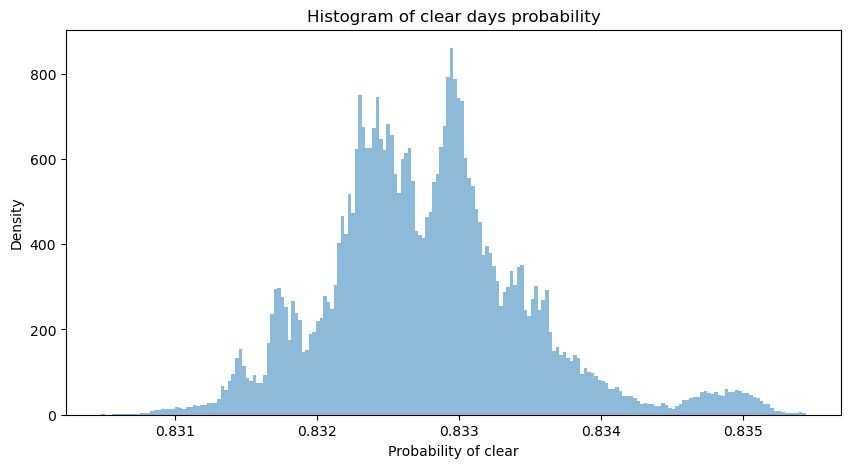

In [10]:
plt.figure(figsize=(10,5))
plt.hist(p_clear[burn:], bins=200, density=True, alpha=0.5)
plt.title("Histogram of clear days probability")
plt.xlabel('Probability of clear')
plt.ylabel('Density')
plt.show()

In [11]:
print("Probability of clear: summary statistics\n")
print("Median = {:.4f}".format(np.median(p_clear[burn:])))
print("SigmaG = {:.4f}\n".format(sigmaG(p_clear[burn:])))
print("Mean = {:.4f}".format(np.mean(p_clear[burn:])))
print("Sigma = {:.4f}\n".format(np.std(p_clear[burn:])))
print("Min-Max = {:.4f}-{:.4f}".format(min(p_clear[burn:]), max(p_clear[burn:])))

Probability of clear: summary statistics

Median = 0.8327
SigmaG = 0.0006

Mean = 0.8328
Sigma = 0.0007

Min-Max = 0.8305-0.8354


In [12]:
# Now just repeat a few times the MC algorithm
vec_p_cloudy = []
vec_p_clear = []
for j in range(20):
  N = 100000
  counter_0 = 0
  counter_1 = 0
  days = np.zeros(N)
  days[0] = start_day

  p_cloudy = np.zeros(N)
  p_cloudy[0] = 1
  p_clear = np.zeros(N)

  for i in range(N-1):
    days[i+1] = MC(days[i])
    if days[i+1] == 0:
      counter_0 += 1
    p_cloudy[i+1] = counter_0/(i+1)
    if days[i+1] == 1:
      counter_1 += 1
    p_clear[i+1] = counter_1/(i+1)

  vec_p_cloudy.append(p_cloudy)
  vec_p_clear.append(p_clear)

In [13]:
vec_p_cloudy = np.array(vec_p_cloudy)
vec_p_clear = np.array(vec_p_clear)

In [14]:
vec_p_cloudy_mean = np.mean(vec_p_cloudy, axis=0)
vec_p_clear_mean = np.mean(vec_p_clear, axis=0)

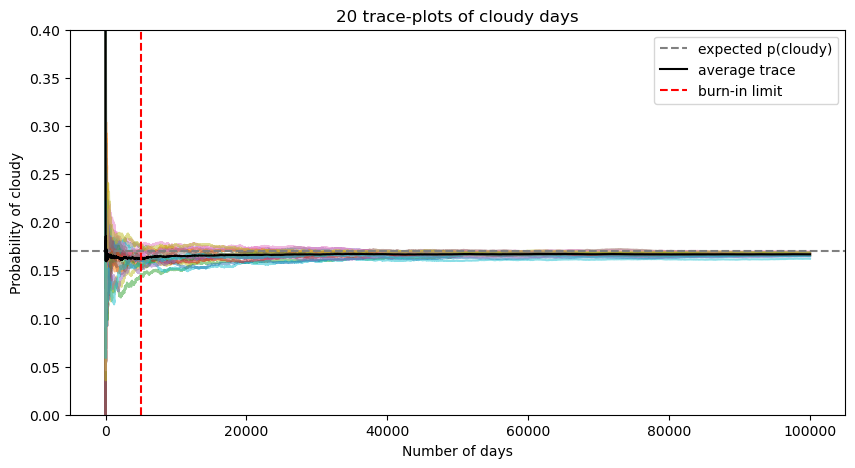

In [15]:
plt.figure(figsize=(10,5))
for j in range(20):
  plt.plot(np.arange(0,N,1), vec_p_cloudy[j], alpha=0.5)
plt.axhline(y=0.17, color='gray', linestyle='--', label="expected p(cloudy)")
plt.plot(np.arange(0,N,1), vec_p_cloudy_mean, "-k", label="average trace")
plt.axvline(x=burn, color='red', linestyle='--', label="burn-in limit")
plt.title("20 trace-plots of cloudy days")
plt.xlabel('Number of days')
plt.ylabel('Probability of cloudy')
plt.ylim(0.0, 0.4)
plt.legend(loc="upper right")
plt.show()

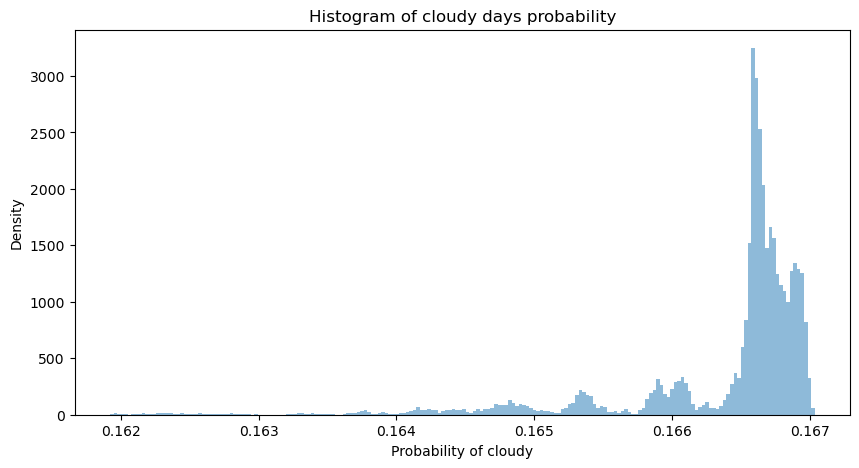

In [16]:
plt.figure(figsize=(10,5))
plt.hist(vec_p_cloudy_mean[burn:], bins=200, density=True, alpha=0.5)
plt.title("Histogram of cloudy days probability")
plt.xlabel('Probability of cloudy')
plt.ylabel('Density')
plt.show()

In [17]:
print("Probability of cloudy: summary statistics\n")
print("Median = {:.4f}".format(np.median(vec_p_cloudy_mean[burn:])))
print("SigmaG = {:.4f}\n".format(sigmaG(vec_p_cloudy_mean[burn:])))
print("Mean = {:.4f}".format(np.mean(vec_p_cloudy_mean[burn:])))
print("Sigma = {:.4f}\n".format(np.std(vec_p_cloudy_mean[burn:])))
print("Min-Max = {:.4f}-{:.4f}".format(min(vec_p_cloudy_mean[burn:]), max(vec_p_cloudy_mean[burn:])))

Probability of cloudy: summary statistics

Median = 0.1666
SigmaG = 0.0002

Mean = 0.1664
Sigma = 0.0007

Min-Max = 0.1619-0.1670


In [18]:
# check total probability
print(np.median(vec_p_cloudy_mean[burn:])+np.median(vec_p_clear_mean[burn:]))

0.9999999999999999
